## FIGURE 6 for WUS CMIP6 WARMING PAPER

In [18]:
import netCDF4
#import h5netcdf
import xarray as xr
import scipy
import os
import numpy as np
import xeofs as xeo
import scipy.stats as stats
import warnings
import matplotlib.pyplot as plt
import scipy.signal as signal
import pandas as pd
import cartopy.crs as ccrs
import cartopy
import seaborn as sns
import xskillscore as xsc
import json


def fix_coords_lon(ds):
    ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180)).sortby(['longitude','latitude'])
    return ds

def fix_coords_lon_lat(ds):
    ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby(['lon','lat'])
    return ds

wusbox = [-125, -102, 32,  49]


In [19]:
# model ensemble members with pyRTE-simulated trends close to actual model reported trends (see Figure s1 notebook)
modmembers_valid_pyrte = {}
with open('/home/tessj/wus_temp_trends/modmembers_trendwithin5wm2_pyrte_lwd_clr.json', 'r') as file:
        modmembers_valid_pyrte = json.load(file)

In [20]:
# open CMIP6 data
ds_lwd_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_lwd_avgs.nc')
ds_lwd_avg_51_80_m_clim = ds_lwd_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_lwd_avg_51_80_m_anom = ds_lwd_avg.groupby('time.month') - ds_lwd_avg_51_80_m_clim
ds_lwd_avg_51_80_m_anom_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_avg_51_80_m_anom_szn[szn] = ds_lwd_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    
ds_lwd_avg_51_80_m_anom_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_avg_51_80_m_anom_trend_szn[szn] = ds_lwd_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


In [21]:
# all-sky LWD
ds_lwd_clr_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_rldscs_avgs.nc')
ds_lwd_clr_avg_51_80_m_clim = ds_lwd_clr_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_lwd_clr_avg_51_80_m_anom = ds_lwd_clr_avg.groupby('time.month') - ds_lwd_clr_avg_51_80_m_clim
ds_lwd_clr_avg_51_80_m_anom_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_clr_avg_51_80_m_anom_szn[szn] = ds_lwd_clr_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

ds_lwd_clr_avg_51_80_m_anom_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_clr_avg_51_80_m_anom_trend_szn[szn] = ds_lwd_clr_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


In [22]:
# all pressure-level data model ensemble members
with open('/home/tessj/wus_temp_trends/modmembers_allvars_WUS_subset_forpyrte.json', 'r') as file:
        modmembers_pl_all = json.load(file)
        

In [26]:
# models with CMIP6 LWD values
models_fig4 = list(ds_lwd_avg.model.values)

In [45]:
# open all results from pyRTE runs
## SELECT ONLY FOR "VALID" MODEL ENSEMBLE RUNS
cmip6_ensmean_pyrte_clr_lwd_trend = []
cmip6_ensmean_pyrte_clr_lwd_tempdetrend_trend = []
cmip6_ensmean_pyrte_clr_lwd_tempdetrend_era5h2otrend_trend = []
cmip6_ensmean_pyrte_clr_lwd_era5h2otrend_trend = []
cmip6_ensmean_pyrte_clr_lwd_q1980_trend = []
cmip6_ensmean_lwd_clr = []
cmip6_ensmean_lwd = []


for model in models_fig4:
    print(model)
    if model in list(modmembers_valid_pyrte.keys())[:-1]:
        cmip6_ensmean_pyrte_clr_lwd_trend.append(xr.open_dataset(f'/home/tessj/wus_temp_trends/pyRTE-RRTMGP/examples/CMIP6_LWD_sfc_clr/{model}_lwd_members.nc').sel(member_id = modmembers_valid_pyrte[model]).polyfit(dim='year', deg=1).sel(degree=1).h2o_polyfit_coefficients.mean('member_id').item())
        cmip6_ensmean_pyrte_clr_lwd_tempdetrend_trend.append(xr.open_dataset(f'/home/tessj/wus_temp_trends/pyRTE-RRTMGP/examples/CMIP6_LWD_sfc_clr/{model}_lwd_members_tempdetrend.nc').sel(member_id = modmembers_valid_pyrte[model]).polyfit(dim='year', deg=1).sel(degree=1).h2o_polyfit_coefficients.mean('member_id').item())
        cmip6_ensmean_pyrte_clr_lwd_tempdetrend_era5h2otrend_trend.append(xr.open_dataset(f'/home/tessj/wus_temp_trends/pyRTE-RRTMGP/examples/CMIP6_LWD_sfc_clr/{model}_lwd_members_tempdetrend_era5h2otrend.nc').sel(member_id = modmembers_valid_pyrte[model]).polyfit(dim='year', deg=1).sel(degree=1).h2o_polyfit_coefficients.mean('member_id').item())
        cmip6_ensmean_pyrte_clr_lwd_q1980_trend.append(xr.open_dataset(f'/home/tessj/wus_temp_trends/pyRTE-RRTMGP/examples/CMIP6_LWD_sfc_clr/{model}_lwd_members_q1980.nc').sel(member_id = modmembers_valid_pyrte[model]).polyfit(dim='year', deg=1).sel(degree=1).h2o_polyfit_coefficients.mean('member_id').item())
        cmip6_ensmean_lwd_clr.append(ds_lwd_clr_avg_51_80_m_anom_trend_szn['JFM'].sel(model=model).rldscs_wus_polyfit_coefficients.item())
        cmip6_ensmean_lwd.append(ds_lwd_avg_51_80_m_anom_trend_szn['JFM'].sel(model=model).lwd_wus_polyfit_coefficients.item())
        cmip6_ensmean_pyrte_clr_lwd_era5h2otrend_trend.append(xr.open_dataset(f'/home/tessj/wus_temp_trends/pyRTE-RRTMGP/examples/CMIP6_LWD_sfc_clr/{model}_lwd_members_era5h2otrend.nc').sel(member_id = modmembers_valid_pyrte[model]).polyfit(dim='year', deg=1).sel(degree=1).h2o_polyfit_coefficients.mean('member_id').item())
    # if models don't have valid pyrte members
    else:
        print('nan model')
        cmip6_ensmean_pyrte_clr_lwd_trend.append(np.nan)
        cmip6_ensmean_pyrte_clr_lwd_tempdetrend_trend.append(np.nan)
        cmip6_ensmean_pyrte_clr_lwd_tempdetrend_era5h2otrend_trend.append(np.nan)
        cmip6_ensmean_pyrte_clr_lwd_q1980_trend.append(np.nan)
        cmip6_ensmean_pyrte_clr_lwd_era5h2otrend_trend.append(np.nan)
        cmip6_ensmean_lwd_clr.append(np.nan)
        cmip6_ensmean_lwd.append(np.nan)

GFDL-ESM4
nan model
IPSL-CM6A-LR
CNRM-CM6-1
MRI-ESM2-0
CNRM-ESM2-1
CanESM5
CanESM5-CanOE
UKESM1-0-LL
MIROC6
MPI-ESM1-2-LR
CESM2-WACCM
FGOALS-g3
MIROC-ES2L
NorESM2-LM
nan model
ACCESS-CM2
KACE-1-0-G
FIO-ESM-2-0
GISS-E2-1-G
nan model
EC-Earth3-Veg
EC-Earth3
CESM2


In [28]:
# df of pyRTE results for individual CMIP6 ensemble members and ensemble mean
cmip6_ensmean_pyrte_df = pd.DataFrame(cmip6_ensmean_pyrte_clr_lwd_trend, columns = ['CMIP6 T, q'])
cmip6_ensmean_pyrte_df['CMIP6 $\overline{T}$, q'] = cmip6_ensmean_pyrte_clr_lwd_tempdetrend_trend
cmip6_ensmean_pyrte_df['CMIP6 $\overline{T}$, ERA5 q trend'] = cmip6_ensmean_pyrte_clr_lwd_tempdetrend_era5h2otrend_trend
cmip6_ensmean_pyrte_df['CMIP6 T, ERA5 q trend'] = cmip6_ensmean_pyrte_clr_lwd_era5h2otrend_trend

cmip6_ensmean_pyrte_df['CMIP6 clear-sky LWD'] = cmip6_ensmean_lwd_clr
cmip6_ensmean_pyrte_df['CMIP6 LWD'] = cmip6_ensmean_lwd


In [46]:
cmip6_ensmean_pyrte_df

,"CMIP6 T, q","CMIP6 $\overline{T}$, q","CMIP6 $\overline{T}$, ERA5 q trend","CMIP6 T, ERA5 q trend",CMIP6 clear-sky LWD,CMIP6 LWD
0,NaN,NaN,NaN,NaN,NaN,NaN
1,0.130998,0.048207,-0.055838,0.026957,0.157136,0.146779
2,0.139414,0.069916,-0.020133,0.049371,0.142092,0.135382
3,0.211172,0.126882,0.020387,0.104687,0.196982,0.141452
4,0.130045,0.071613,-0.013754,0.044683,0.146670,0.137965
5,0.205778,0.064236,-0.056674,0.084869,0.222304,0.207003
6,0.189526,0.063194,-0.056401,0.069935,0.205429,0.216357
7,0.182729,0.068168,-0.056508,0.058056,0.197424,0.177636
8,0.159179,0.087220,-0.005710,0.066253,0.188856,0.168734
9,0.085725,0.024811,-0.053746,0.007170,0.120244,0.077727


In [15]:
# ERA5 WUS-averaged JFM LWD trend (see Figure s1 and s3 notebook for calculation)
ERA5_lwd_jfm_trend = np.float64(-1.7236339743757363)

# same but clear-sky  (see Figure s1 and s3 notebook for calculation)
ERA5_lwd_clr_jfm_trend = 0.7375459656228737

# pyRTE LWD trend given ERA5 T and q profiles (see pyRTE notebook for calculation)
ERA5_pyrte_lwd = np.float64(-2.200686819945355)

# same but given fixed 1980 temperatures from ERA5 (see pyRTE notebook for calculation)
ERA5_pyrte_lwd_temp1980 = np.float64(-2.2495023118862996)

# same but given detrended temperatures from ERA5 (see pyRTE notebook for calculation)
ERA5_pyrte_lwd_tempdetrend = np.float64(-2.263649909123405)


In [17]:
barplot_df = pd.DataFrame([{'ERA5 LWD':ERA5_lwd_jfm_trend, 'ERA5 clear-sky LWD':ERA5_lwd_clr_jfm_trend,
                            'CMIP6 LWD':45*np.nanmean(cmip6_ensmean_lwd),'CMIP6 clear-sky LWD':45*np.nanmean(cmip6_ensmean_lwd_clr), 
                            'ERA5 T, q':ERA5_pyrte_lwd, 'ERA5 $\overline{T}$, q':ERA5_pyrte_lwd_tempdetrend, 
                           'CMIP6 T, q':45*np.nanmean(cmip6_ensmean_pyrte_clr_lwd_trend),
                            'CMIP6 T, ERA5 q trend':45*np.nanmean(cmip6_ensmean_pyrte_clr_lwd_era5h2otrend_trend),
                           'CMIP6 $\overline{T}$, q': 45*np.nanmean(cmip6_ensmean_pyrte_clr_lwd_tempdetrend_trend),
                           'CMIP6 $\overline{T}$, ERA5 q trend': 45*np.nanmean(cmip6_ensmean_pyrte_clr_lwd_tempdetrend_era5h2otrend_trend)}])

In [21]:
barplot_df.iloc[:, [0, 1,2,3, 6,8,9]]

,ERA5 LWD,ERA5 clear-sky LWD,CMIP6 LWD,CMIP6 clear-sky LWD,"CMIP6 T, q","CMIP6 $\overline{T}$, q","CMIP6 $\overline{T}$, ERA5 q trend"
0,-1.723634,0.737546,7.299823,8.244535,7.064881,2.830312,-1.658206


### Plot Figure 6

/tmp/ipykernel_22577/1424781489.py:2: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  sns.barplot(barplot_df.iloc[:, [0, 1,2,3, 6,8,9]], palette=['#0173b2','#0173b2', '#0173b2', '#0173b2', '#de8f05', '#de8f05', '#de8f05', 'y', 'y', 'y'])


Text(0.0, 1.0, 'Surface LWD trends')

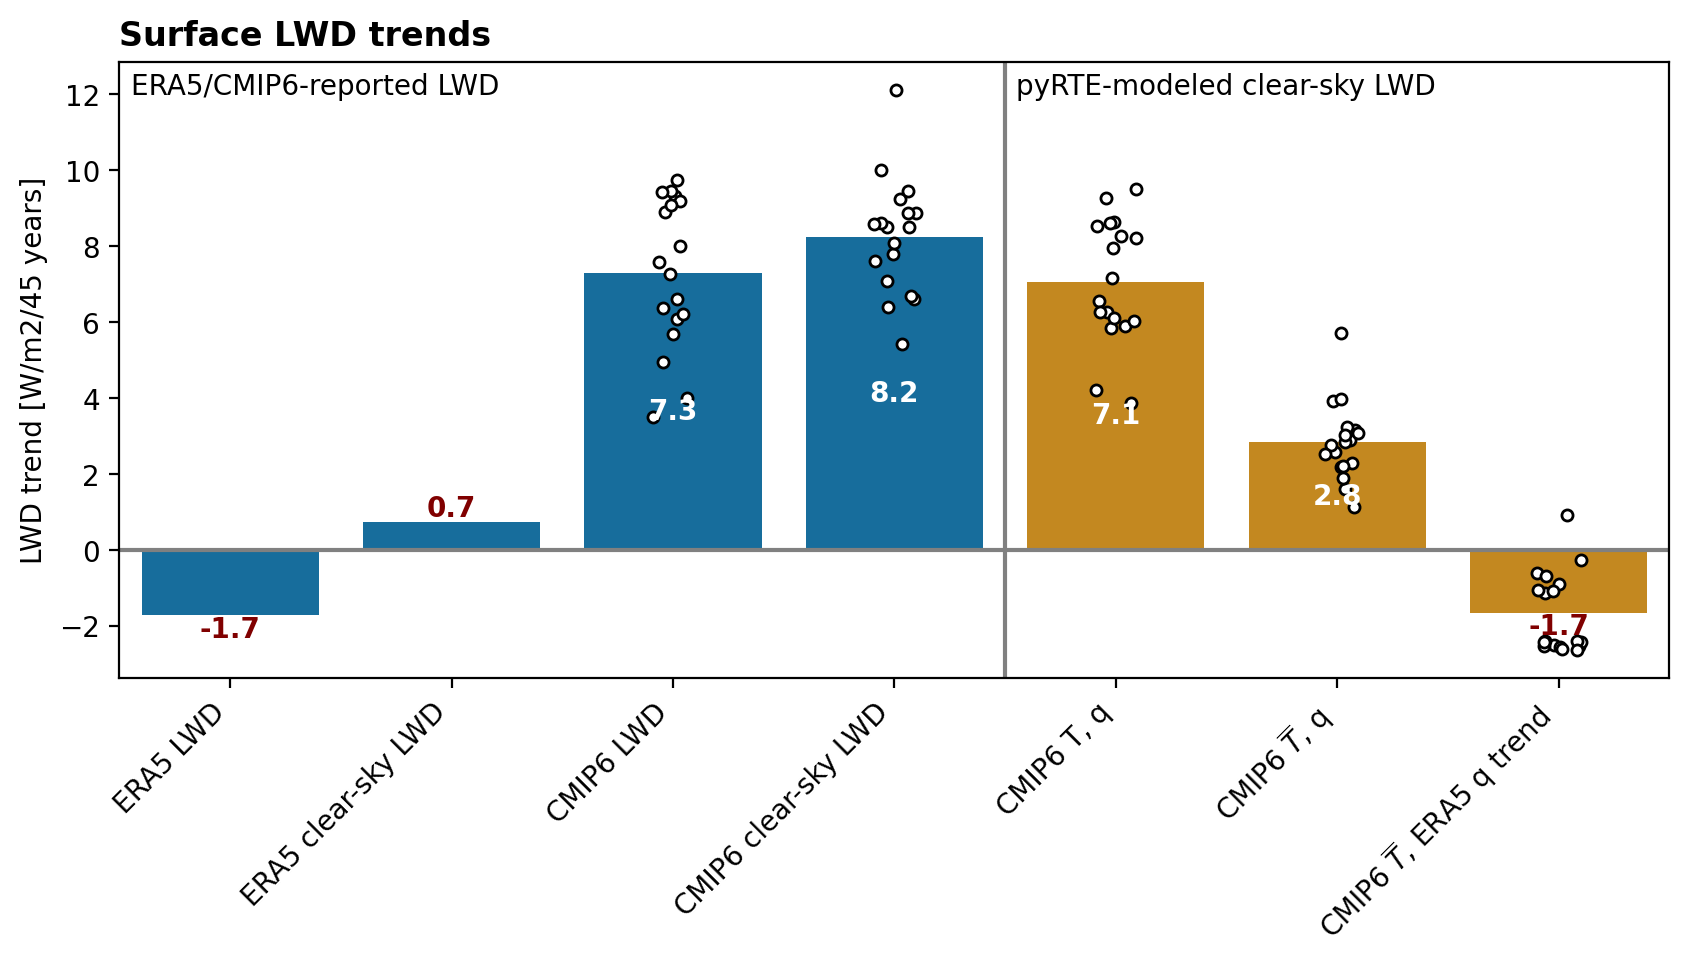

In [38]:
palette='colorblind'
fig, ax = plt.subplots(1,1, figsize=(10,4), dpi=200)
sns.barplot(barplot_df.iloc[:, [0, 1,2,3, 6,8,9]], palette=['#0173b2','#0173b2', '#0173b2', '#0173b2', '#de8f05', '#de8f05', '#de8f05', 'y', 'y', 'y'])
sns.stripplot(45*cmip6_ensmean_pyrte_df.iloc[:, [0,1,2,4,5]], marker = 'o', edgecolor='k', color='white',linewidth=1, size=4)

for ii, container in enumerate(ax.containers):
    if ii in [0,1,6]: ax.bar_label(container, fmt='%.1f', label_type='edge', c='maroon', fontweight='bold') # 'edge' or 'center'
    else: ax.bar_label(container, fmt='%.1f', label_type='center', c='white', fontweight='bold') # 'edge' or 'center'

    
plt.xticks(rotation=45, ha='right')
ax.axhline(0, c='grey')
ax.axvline(3.5, c='grey')
ax.set_ylabel('LWD trend [W/m2/45 years]')
ax.text(s='pyRTE-modeled clear-sky LWD', x=3.55, y=12)
ax.text(s='ERA5/CMIP6-reported LWD', x=-0.45, y=12)
ax.set_title('Surface LWD trends', fontweight='bold', loc='left')

### save out discrepancy contributions for Figure 7

In [48]:
barplot_df_v1 = barplot_df.copy()
barplot_df_v1['ERA5 cloud LW effect'] = barplot_df_v1['ERA5 LWD'] - barplot_df_v1['ERA5 clear-sky LWD']
barplot_df_v1['CMIP6 cloud LW effect'] = barplot_df_v1['CMIP6 LWD'] - barplot_df_v1['CMIP6 clear-sky LWD']

In [49]:
barplot_discrepancy = pd.DataFrame()
barplot_discrepancy['LWD discrepancy'] = barplot_df_v1['CMIP6 LWD'] - barplot_df_v1['ERA5 LWD']
barplot_discrepancy['q trend contribution']  = barplot_df_v1['CMIP6 $\overline{T}$, q'] - barplot_df_v1['CMIP6 $\overline{T}$, ERA5 q trend'] 
barplot_discrepancy['Cloud LWD effect contribution'] = barplot_df_v1['CMIP6 cloud LW effect'] - barplot_df_v1['ERA5 cloud LW effect'] 


In [50]:
cmip6_ensmean_pyrte_df_discrepancy = pd.DataFrame()
cmip6_ensmean_pyrte_df_discrepancy['LWD discrepancy'] =  (45*cmip6_ensmean_pyrte_df['CMIP6 LWD']) - barplot_df_v1['ERA5 LWD'][0]
cmip6_ensmean_pyrte_df_discrepancy['q trend contribution'] = 45*(cmip6_ensmean_pyrte_df['CMIP6 $\overline{T}$, q'] - cmip6_ensmean_pyrte_df['CMIP6 $\overline{T}$, ERA5 q trend'] )
cmip6_ensmean_pyrte_df_discrepancy['Cloud LWD effect contribution'] = 45*cmip6_ensmean_pyrte_df['CMIP6 LWD'] - 45*cmip6_ensmean_pyrte_df['CMIP6 clear-sky LWD'] - barplot_df_v1['ERA5 cloud LW effect'][0]


In [51]:
import pickle
cmip6_ensmean_pyrte_df_discrepancy.to_pickle('/home/tessj/wus_temp_trends/cmip6_ensmean_pyrte_df_discrepancy.pkl')
barplot_discrepancy.to_pickle('/home/tessj/wus_temp_trends/cmip6_ensmean_pyrte_df_discrepancy_means.pkl')